In [9]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def delta_pct(lhs: np.ndarray, rhs: np.ndarray, decimals: int = 2 ) -> np.ndarray:
    return ((lhs-rhs)*100).round(decimals)

In [11]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [12]:
baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"
cutoff_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "cutoff_v3"

In [13]:
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)
cutoff_recalls, cutoff_precisions = get_precisions_recalls(cutoff_path)

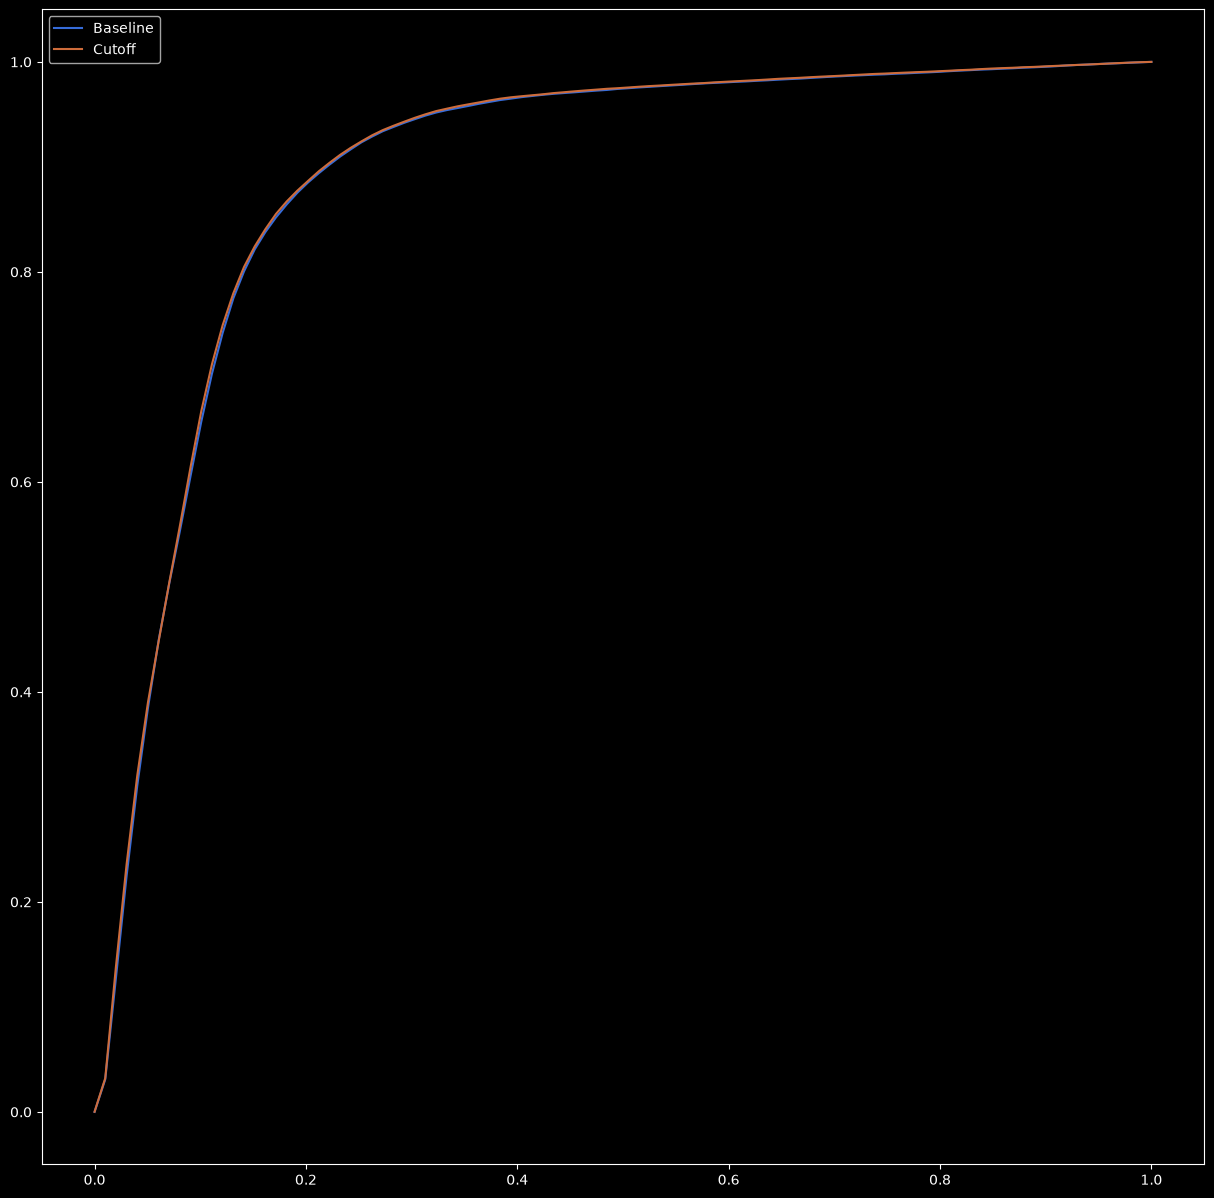

In [14]:
plt.figure(figsize=(15, 15))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0),
         label="Baseline")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(cutoff_recalls).mean(axis=0),
         label="Cutoff")
plt.legend()

In [15]:
delta_pct(
    lhs = np.array(cutoff_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
)

array([ 0.01,  0.11,  1.07,  1.11,  0.97,  0.53, -0.09,  0.08,  0.49,
        0.85,  1.  ,  0.9 ,  0.73,  0.48,  0.42,  0.29,  0.27,  0.33,
        0.28,  0.2 ,  0.14,  0.18,  0.17,  0.16,  0.14,  0.09,  0.12,
        0.1 ,  0.11,  0.11,  0.13,  0.12,  0.14,  0.13,  0.16,  0.15,
        0.13,  0.14,  0.13,  0.13,  0.09,  0.07,  0.05,  0.07,  0.08,
        0.09,  0.1 ,  0.09,  0.11,  0.07,  0.07,  0.06,  0.07,  0.06,
        0.06,  0.05,  0.05,  0.03,  0.05,  0.06,  0.06,  0.07,  0.06,
        0.07,  0.08,  0.08,  0.08,  0.07,  0.06,  0.05,  0.05,  0.05,
        0.06,  0.07,  0.07,  0.06,  0.07,  0.06,  0.06,  0.06,  0.04,
        0.05,  0.04,  0.05,  0.06,  0.05,  0.05,  0.04,  0.04,  0.04,
        0.03,  0.01,  0.01,  0.01, -0.01,  0.01,  0.01,  0.01,  0.01,
        0.  ])

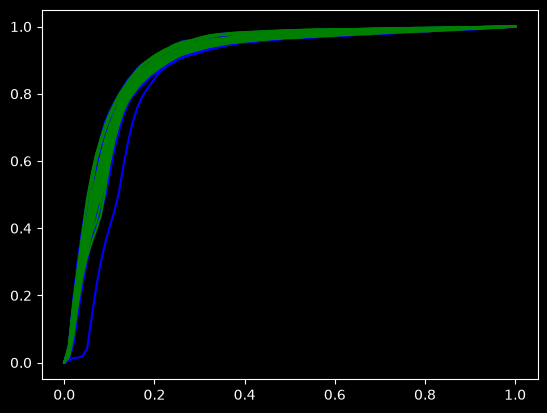

In [16]:



for i in range(30):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls)[i],
         label="Baseline Recalls", color ="blue")


for i in range(len(cutoff_recalls)):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(cutoff_recalls)[i],
         label="Cutoff Recalls", color ="green")